In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("../data/student-mat.csv", sep = ";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [39]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

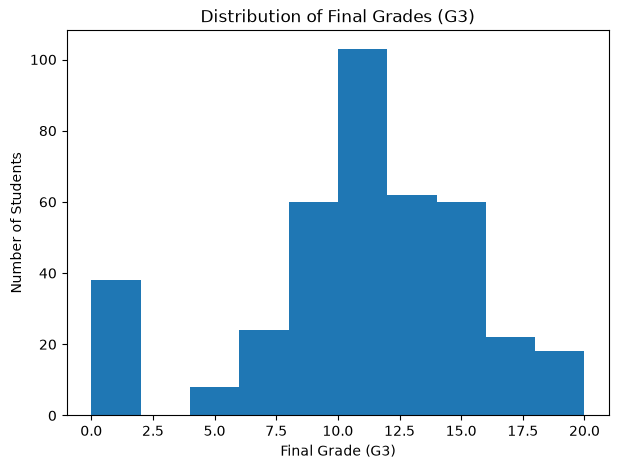

In [43]:
plt.figure(figsize = (7, 5))
plt.hist(df["G3"], bins = 10)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

In [45]:
df.select_dtypes(include = "str").columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

In [46]:
df_encoded = df.copy()

In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for column in df_encoded.select_dtypes(include='str').columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

In [52]:
df_encoded.dtypes

school        int64
sex           int64
age           int64
address       int64
famsize       int64
Pstatus       int64
Medu          int64
Fedu          int64
Mjob          int64
Fjob          int64
reason        int64
guardian      int64
traveltime    int64
studytime     int64
failures      int64
schoolsup     int64
famsup        int64
paid          int64
activities    int64
nursery       int64
higher        int64
internet      int64
romantic      int64
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [68]:
y = df_encoded["G3"]
X = df_encoded.drop("G3", axis = 1)
y.shape

(395,)

In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [78]:
y_train.shape

(316,)

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
X_train_scaled[:5]

array([[-0.34722813,  1.07906606, -0.58639605,  0.52853782, -0.63105474,
         0.33567254,  0.24643712,  0.42320737,  0.69723897, -0.26611339,
        -0.21239806,  0.25336673, -0.62577865, -0.05685286, -0.45674383,
        -0.40219983, -1.23612297,  1.08596056,  1.00634927,  0.49901088,
         0.24576958,  0.43869446,  1.37807205,  0.06443217, -1.19598096,
        -0.14439599, -0.55443033, -0.2664957 , -0.36847328, -0.46440769,
         0.33205033,  0.62616324],
       [-0.34722813,  1.07906606, -0.58639605,  0.52853782, -0.63105474,
         0.33567254, -0.68063585,  0.42320737, -0.10982152, -0.26611339,
        -0.21239806, -1.60858415,  0.82823645, -1.25455313, -0.45674383,
        -0.40219983, -1.23612297, -0.92084375, -0.99369079,  0.49901088,
         0.24576958,  0.43869446, -0.72565146,  1.19557467, -0.21434464,
        -0.14439599, -0.55443033, -1.03908875, -0.36847328, -0.70225668,
         0.64340909,  0.89283114],
       [-0.34722813, -0.92672732, -0.58639605,  0.5285

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [84]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_predictions = lr.predict(X_test_scaled)
lr_predictions[:10]

array([ 6.28152491, 11.32691676,  3.03252133,  8.03726136,  8.55577788,
       12.36703933, 18.68481592,  7.54069216,  6.98823227, 12.36020452])

In [85]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_predictions
})
comparison.head(10)

,Actual,Predicted
0,10,6.281525
1,12,11.326917
2,5,3.032521
3,10,8.037261
4,9,8.555778
5,13,12.367039
6,18,18.684816
7,6,7.540692
8,0,6.988232
9,14,12.360205


In [86]:
mae = mean_absolute_error(y_test, lr_predictions)
print("MAE", mae)

MAE 1.495475010052277


In [87]:
mse = mean_squared_error(y_test, lr_predictions)
print("MSE", mse)

MSE 5.032394108866743


In [88]:
import numpy as np

In [89]:
rmse = np.sqrt(mse)
print("RMSE", rmse)

RMSE 2.243299825896383


In [90]:
r2 = r2_score(y_test, lr_predictions)
print("R2 Score", r2)

R2 Score 0.7545777855043498


In [91]:
dt = DecisionTreeRegressor(random_state = 42)
dt.fit(X_train_scaled, y_train)
dt_predictions = dt.predict(X_test_scaled)
print("MAE:", mean_absolute_error(y_test, dt_predictions))
print("MSE:", mean_squared_error(y_test, dt_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_predictions)))
print("R2:", r2_score(y_test, dt_predictions))

MAE: 1.2784810126582278
MSE: 5.6075949367088604
RMSE: 2.3680360927800193
R2: 0.7265261150876754


In [92]:
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train_scaled, y_train)
rf_predictions = rf.predict(X_test_scaled)
print("MAE:", mean_absolute_error(y_test, dt_predictions))
print("MSE:", mean_squared_error(y_test, dt_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_predictions)))
print("R2:", r2_score(y_test, dt_predictions))

MAE: 1.2784810126582278
MSE: 5.6075949367088604
RMSE: 2.3680360927800193
R2: 0.7265261150876754


In [93]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, dt_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_predictions)),
        np.sqrt(mean_squared_error(y_test, dt_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions))
    ],
    "R2 Score": [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.495475,2.243300,0.754578
1,Decision Tree,1.278481,2.368036,0.726526
2,Random Forest,1.121013,1.873620,0.828801


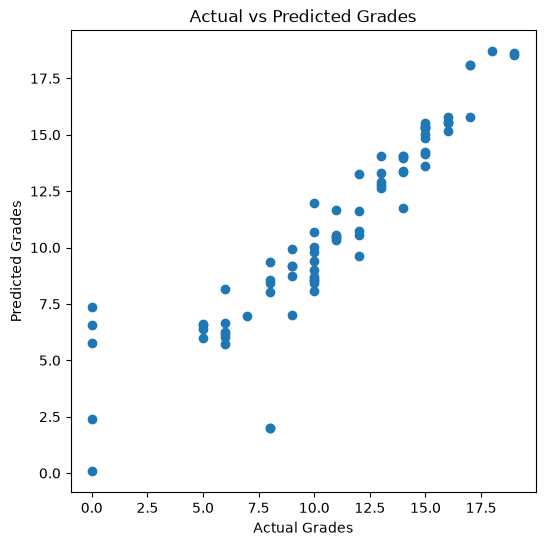

In [94]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Grades")

plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted Grades")

plt.show()

In [95]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
31,G2,0.792518
29,absences,0.110344
2,age,0.015196
10,reason,0.010257
30,G1,0.007557
23,famrel,0.006354
8,Mjob,0.006137
22,romantic,0.005654
28,health,0.004655
18,activities,0.004456
